<a href="https://colab.research.google.com/github/GyL-nm/cnn-classifier_cifar-10/blob/main/220635295_CNN_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch, torch.nn as nn, torchvision, torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Sourced from https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
transform = torchvision.transforms.Compose([transforms.RandomHorizontalFlip(),
                                            transforms.RandomCrop(size=[32,32], padding=4),
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
BATCH_SIZE = 4

training_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
training_loader = torch.utils.data.DataLoader(training_data, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=2)

test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=2)

CLASSES = tuple(training_data.classes)

training_batcher = iter(training_loader)

print(training_data.meta)
print(CLASSES);

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# get some random training images
images, labels = next(training_batcher)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{CLASSES[labels[j]]:5s}' for j in range(BATCH_SIZE)))

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


{'filename': 'batches.meta', 'key': 'label_names', 'md5': '5ff9c542aee3614f3951f8cda6e48888'}
('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


 # Conv2d Block

 Combines n*[Conv2d => ReLU] => MaxPool2d into a single unit:
 - Each Conv2d is individually configurable
 - CNN_Block1 variant simply defines Conv2d => ReLU => MaxPool2d, used specifically in Stem

In [ ]:
class CNN_Block(nn.Module):
    def __init__(self, convs, pool=(2,2)):
        super(CNN_Block, self).__init__()
        self.num_convs = len(convs)


        self.convs = nn.ModuleList()
        for i, (in_channel, out_channel, kernel_size, stride, padding) in enumerate(convs):
          self.convs.append(nn.Conv2d(in_channel, out_channel,
                                      kernel_size=kernel_size, padding=padding))

        pool_kernel, pool_stride = pool
        self.max_pool = nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
      out = x
      for conv in self.convs:
        out = self.relu(conv(out))

      out = self.max_pool(out)

      return out

class CNN_Block1(CNN_Block):
    def __init__(self, in_channel, out_channel, kernel, stride, padding, pool=(2,2)):
      super(CNN_Block1, self).__init__(( (in_channel, out_channel, kernel, stride, padding),), pool)

In [ ]:
test_block = CNN_Block(
    ((3,16,5,1,0),
    (16,32,3,1,0),
    (32,64,3,2,0)) , (2,2))

print(test_block)

test_block = CNN_Block1(
    3,16,5,1,0, (3,3))

print(test_block)

CNN_Block(
  (convs): ModuleList(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  )
  (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
)
CNN_Block1(
  (convs): ModuleList(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  )
  (max_pool): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
)


 # Stem
 ## Variable Stem
 Combines n*[CNN_Block]
 - Completely customisable
 - Superclass for all stems


 ## Simple Variable Stem
 Combines n*[CNN_Block1] where all blocks are identical
 - Used for easy prototyping


 ## CNN Stem
 Simple default configuration
 - Used mostly in testing

In [ ]:
class CNN_Variable_Stem(nn.Module):
  def __init__(self, blocks):
    super(CNN_Variable_Stem, self).__init__()

    self.blocks = nn.ModuleList(blocks)

  def forward(self, x):
    out = x

    for block in self.blocks:
      out = block(out)

    return out

class CNN_Simple_Variable_Stem(CNN_Variable_Stem): # for configuration testing
  def __init__(self, in_channels, out_channels, kernel, stride, padding, pool_kernel, pool_stride):

    if len(in_channels) != len(out_channels):
      raise Exception("in_channel must equal out_channel.")

    blocks = nn.ModuleList(
        CNN_Block1(in_channel,out_channel,kernel,stride,padding,(pool_kernel,pool_stride))
        for in_channel,out_channel in zip(in_channels,out_channels)
        )

    super(CNN_Simple_Variable_Stem, self).__init__(blocks)

  def forward(self, x):
    out = x

    for block in self.blocks:
      out = block(out)

    return out

class CNN_Stem(CNN_Variable_Stem):
  def __init__(self):
    blocks = [
        CNN_Block1( 3,16,5,1,2 ,(2,2)),
        CNN_Block1( 16,32,3,1,2 ,(2,2)),
        CNN_Block1( 32,64,3,1,2 ,(2,2))]

    super(CNN_Stem, self).__init__(blocks)

In [ ]:
test_stem = CNN_Stem()
print(test_stem)

input_image = torch.randn(1, 3, 32, 32)

out = test_stem(input_image)
print(out.shape)

test_stem = CNN_Variable_Stem(
        [CNN_Block1( 3,16,5,1,2 ,(2,2))]
)
print(test_stem)

input_image = torch.randn(1, 3, 32, 32)

out = test_stem(input_image)
print(out.shape)

test_stem = CNN_Simple_Variable_Stem(
    (3,16,32), (16,32,64), 5,1,2, 2,2)
print(test_stem)

input_image = torch.randn(1, 3, 32, 32)

out = test_stem(input_image)
print(out.shape)

CNN_Stem(
  (blocks): ModuleList(
    (0): CNN_Block1(
      (convs): ModuleList(
        (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU(inplace=True)
    )
    (1): CNN_Block1(
      (convs): ModuleList(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU(inplace=True)
    )
    (2): CNN_Block1(
      (convs): ModuleList(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2))
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU(inplace=True)
    )
  )
)
torch.Size([1, 64, 5, 5])
CNN_Variable_Stem(
  (blocks): ModuleList(
    (0): CNN_Block1(
      (convs): ModuleList(
        (0): Conv2d(3, 16, kernel_size=(5, 

 # Back-bone

 ## Expert Branch
 Expert calculates weighted average of Conv2d in the block
 - Decides how much to emphasise each convolution

 ## Expert Block
 Block that applies sum of weighted Conv2ds
 - Using identical Conv2d parameters makes model less prone to overfitting

In [ ]:
class CNN_Expert_Branch(nn.Module):
  def __init__(self, in_channel, r, k):
    super(CNN_Expert_Branch, self).__init__()

    cr = max(in_channel // r, 1)
    self.pool = nn.AdaptiveAvgPool2d(1)
    self.fc1 = nn.Conv2d(in_channel, cr, 1)
    self.g = nn.ReLU(inplace=True)
    self.fc2 = nn.Conv2d(cr,k,1)
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    out = x
    # print(x.shape)

    out = self.pool(x)
    # print(out.shape)

    out = self.fc1(out)
    # print(out.shape)

    out = self.g(out)
    # print(out.shape)

    out = self.fc2(out)
    # print(out.shape)

    out = self.softmax(out)
    # print(out.shape)

    return out

class CNN_Expert_Block(CNN_Block):
    def __init__(self, num_convs, in_channel, out_channel, kernel_size, stride, padding, pool):
      convs = [(in_channel, out_channel, kernel_size, stride, padding) for i in range(num_convs)]
      super(CNN_Expert_Block, self).__init__(convs, pool)
      self.num_convs = num_convs

      self.expert = CNN_Expert_Branch(in_channel, 4, num_convs)


    def forward(self, x):
      a = self.expert(x).squeeze(-1).squeeze(-1)
      # print("a:", a.shape, a)

      out = 0
      for i in range(self.num_convs):
        conv_out = self.relu(self.convs[i](x))

        weight = a[:, i].view(-1, 1, 1, 1)
        out += weight * conv_out

      return out

In [ ]:
stem = CNN_Stem()
x = torch.rand(4,3,32,32)

out = stem(x)
print(out.shape)

block = CNN_Expert_Block(4, 64,128,3,1,1, (2,2))
out = block(out)

print("post:", out.shape)


torch.Size([4, 64, 5, 5])
post: torch.Size([4, 128, 5, 5])


  # Classifier
  MLP classifier with 3 fully-connected layers
  - Uses Conv2d with 1,1 kernel instead of Linear to maintain spatial information, and reduces parameter count
  - ReLU used for activation function
  - Dropout applied to reduce overfitting
  - Use Linear to reduce to 10

In [ ]:
class Classifier_MLP(nn.Module):
  def __init__(self):
    super(Classifier_MLP, self).__init__()

    self.pool = nn.AdaptiveAvgPool2d(1)
    self.fc1 = nn.LazyConv2d(256, 1)
    self.relu = nn.ReLU(inplace=True)
    self.dropout = nn.Dropout(0.5)
    self.fc2 = nn.Conv2d(256, 128, 1)
    self.fc3 = nn.LazyLinear(10)

  def forward(self, x):
    out = self.pool(x)
    out = self.fc1(out)
    out = self.relu(out)
    out = self.dropout(out)
    out = self.fc2(out)
    out = out.view(out.size(0), -1)
    out = self.fc3(out)

    return out

  # CNN
  Combines flow from Stem => Backbone => Classifier
  - Stem, Backbone are customisable

In [ ]:
class CNN(nn.Module):
  def __init__(self, stem, blocks):
    super(CNN, self).__init__()

    self.stem = stem

    self.back_bone = nn.ModuleList(blocks)

    self.classifier = Classifier_MLP()

  def forward(self, x):
    # print("pre_out:", x.shape)

    out = self.stem(x)
    # print("stem_out:", out.shape)

    for i, block in enumerate(self.back_bone):
      # print(f"block{i}_out:", out.shape)
      out = block(out)
      # print(f"block{i}_out:", out.shape)

    out = self.classifier(out)

    return out

In [ ]:
test = CNN(stem=CNN_Variable_Stem([
    CNN_Block1(3, 32, 3, 1, 1, (2, 2)),
    CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    ]),

           blocks=[
    CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    CNN_Expert_Block(2, 128,128,3,1,1, (1,1))
    ])
print(test)
x = torch.rand(16,3,32,32)
o = test(x)
print(o)
print(o.shape)

CNN(
  (stem): CNN_Variable_Stem(
    (blocks): ModuleList(
      (0): CNN_Block1(
        (convs): ModuleList(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (relu): ReLU(inplace=True)
      )
      (1): CNN_Block1(
        (convs): ModuleList(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (relu): ReLU(inplace=True)
      )
    )
  )
  (back_bone): ModuleList(
    (0): CNN_Expert_Block(
      (convs): ModuleList(
        (0-1): 2 x Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU(inplace=True)
      (expert): CNN_Expert_Branch(
        (pool): AdaptiveAvgPool2d

In [ ]:
def init_weights(m, method="normal"):
    if hasattr(m, 'weight'):
      if method == "kaiming":
          torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
      elif method == "xavier":
          torch.nn.init.xavier_uniform_(m.weight)
      elif method == "normal":
          torch.nn.init.normal_(m.weight, mean=0.0, std=0.01)
      if m.bias is not None:
          torch.nn.init.zeros_(m.bias)

  # Train/Testing + Plot
  CNN Models are loaded from configs set to allow for incremental testing of hyperparameters and CNN structure
  - config contains hyperparameter setting (lr, epoch, batch_size, weight_initialisation, optimisation, weight_decay)
  - all configs are plotted against eachother for comparative testing
  - loss evolution, training + testing accuracy evolution is recorded and plotted

In [ ]:
import torch, torch.nn as nn, torchvision, torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

def train_and_test_model(configs):

  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  print(f"Using device: {device}")

  # Load CIFAR-10 and batch
  transform = torchvision.transforms.Compose([transforms.RandomHorizontalFlip(),
                                            transforms.RandomVerticalFlip(),
                                            transforms.RandomCrop(size=[32,32]),
                                            transforms.ToTensor(),
                                            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

  train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
  test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)



  # train and test each configuration
  for config_num, config in enumerate(configs):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False)

    print(config["desc"])
    model = CNN(stem=config["stem"],blocks=config["blocks"]).to(device)
    print(model)

    # model, loss function, optimisation init
      # dummy to initialise lazylinear to allow init_
    dummy = model(torch.rand(BATCH_SIZE,3,32,32).to(device))
    model.apply(lambda m: init_weights(m, method=config["weight_init"]))

    config["train_losses"] = []
    config["train_accuracies"] = [0]
    config["test_accuracies"] = [0]

    criterion = nn.CrossEntropyLoss()  # mlp-appropriate classification
    optimiser = config["optimiser_type"](model.parameters(), config["learning_rate"], weight_decay=config["weight_decay"])

    # model training
    num_epochs = config["epochs"]

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0 # result tracking

        # training loop
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", ncols=100):
            # for cuda
            inputs, labels = inputs.to(device), labels.to(device)

            optimiser.zero_grad()

            # forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # backward + optimisation
            loss.backward()
            optimiser.step()

            # track loss evolution
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        config["train_losses"].append(epoch_loss)
        config["train_accuracies"].append(epoch_acc)

        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")

        # test each epoch to track test accuracy evolution
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                # Move the inputs and labels to GPU
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total
        config["test_accuracies"].append(test_acc)
        print(f"Test Accuracy: {test_acc:.2f}%")

In [ ]:
import matplotlib.patches as mpatch
def plot_results(configs, fit=True):
  epochs = range(1, max(config["epochs"] for config in configs)+1 )

  colours = plt.cm.get_cmap('tab10', len(configs))
  plt.figure(figsize=(max(max(epochs)//1.5,12), 5))

  plt.subplot(1, 2, 1)
  for config_num, config in enumerate(configs):
    colour = colours(config_num)

    loss = config["train_losses"]
    plt.plot(epochs, loss, color=colour, label=config["desc"])
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Training Loss")
  plt.xticks(epochs)
  plt.grid(True)
  plt.legend()


  key = {}

  legend = []
  plt.subplot(1, 2, 2)
  for config_num, config in enumerate(configs):
    train = config["train_accuracies"]
    test = config["test_accuracies"]
    colour = colours(config_num)

    key[config_num] = colour
    legend.append(mpatch.Patch(color=colour, label=config["desc"]))

    plt.plot(epochs, train[1:], linestyle=':', color=colour, label="training")
    plt.plot(epochs, test[1:], color=colour, label="test")

    plt.fill_between(epochs, train[1:], test[1:], color=colour, alpha=0.1)

  plt.xlabel("Epoch")
  plt.ylabel("Accuracy (%)")
  plt.title("Accuracy Evolution")
  plt.grid(True, "both", "x")
  plt.xticks(epochs)
  if not fit:
    plt.yticks(range(0, 101, 10))
  plt.legend(handles=legend)

  plt.tight_layout()
  plt.show()

Using device: cuda
FINAL MODEL
CNN(
  (stem): CNN_Variable_Stem(
    (blocks): ModuleList(
      (0): CNN_Block1(
        (convs): ModuleList(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (relu): ReLU(inplace=True)
      )
      (1): CNN_Block1(
        (convs): ModuleList(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (relu): ReLU(inplace=True)
      )
    )
  )
  (back_bone): ModuleList(
    (0): CNN_Expert_Block(
      (convs): ModuleList(
        (0-3): 4 x Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (relu): ReLU(inplace=True)
      (expert): CNN_Expert_Branch(
  

Epoch 1/25: 100%|███████████████████████████████████████████████| 1563/1563 [00:31<00:00, 49.05it/s]


Epoch 1/25, Loss: 1.6060, Accuracy: 39.40%
Test Accuracy: 53.04%


Epoch 2/25: 100%|███████████████████████████████████████████████| 1563/1563 [00:31<00:00, 49.43it/s]


Epoch 2/25, Loss: 1.1781, Accuracy: 57.56%
Test Accuracy: 63.24%


...

Epoch 24/25: 100%|██████████████████████████████████████████████| 1563/1563 [00:30<00:00, 50.56it/s]


Epoch 24/25, Loss: 0.2737, Accuracy: 90.84%
Test Accuracy: 77.72%


Epoch 25/25: 100%|██████████████████████████████████████████████| 1563/1563 [00:30<00:00, 50.57it/s]


Epoch 25/25, Loss: 0.2652, Accuracy: 91.00%
Test Accuracy: 77.88%


<ipython-input-140-2e6bdf99a73b>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colours = plt.cm.get_cmap('tab10', len(configs))


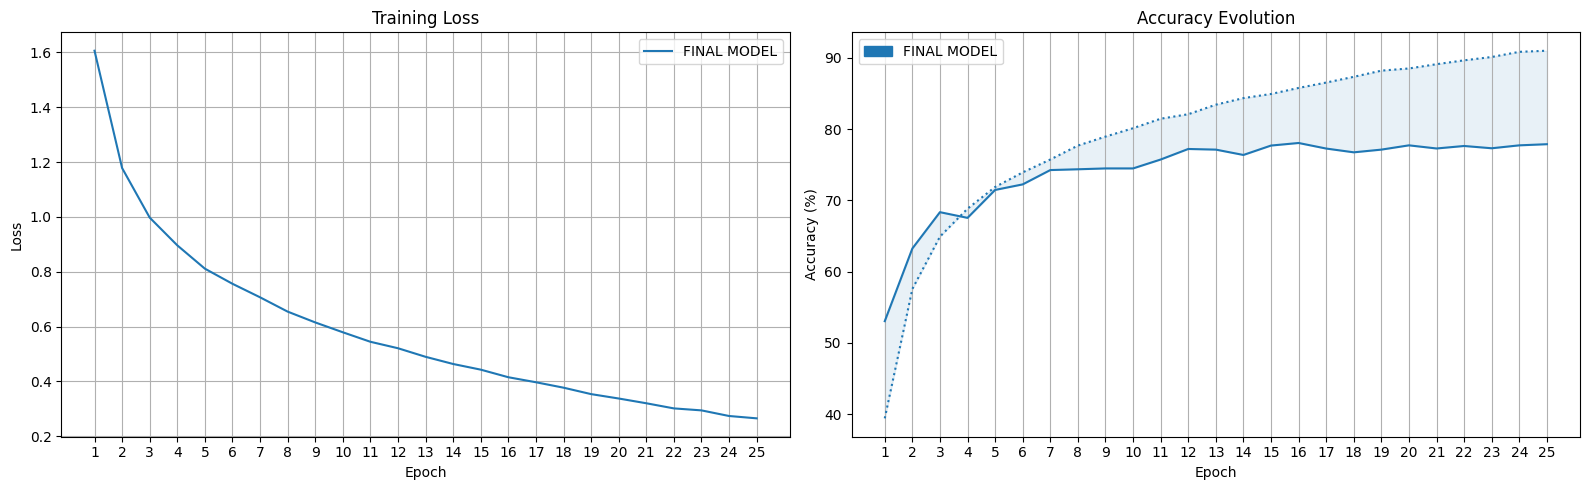

In [ ]:
    # {
configs = [
    {
         "desc": "FINAL MODEL",
         "epochs": 25,

         "optimiser_type": torch.optim.AdamW,
         "learning_rate": 0.001,
         "weight_decay": 0.0001,
         "weight_init": "kaiming",

         "batch_size": 32,
         "stem": CNN_Variable_Stem([
    CNN_Block1(3, 32, 3, 1, 1, (2, 2)),
    CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    ]),
        "blocks":[
    CNN_Expert_Block(4, 64,128,5,1,1, (2,2)),
    CNN_Expert_Block(4, 128,128,3,1,1, (2,2))]
    },
    #     "desc": "baseline",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(4, 128,256,3,1,1, (2,2)),
    # CNN_Expert_Block(4, 256,512,3,1,1, (2,2))]
    # },

    #  {
    #      "desc": "baseline -1 block",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(4, 128,256,3,1,1, (2,2))]
    # },

    # {
    #      "desc": "baseline (new) init:xavier",
    #      "epochs": 25,
    #      "optimiser_type": torch.optim.Adam,
    #      "learning_rate": 0.001,
    #      "weight_init": "xavier",
    #      "stem": CNN_Variable_Stem([
    # CNN_Block1(3, 32, 3, 1, 1, (2, 2)),
    # CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    # ]),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,128,3,1,1, (1,1))]
    # },

    # {
    #      "desc": "baseline (new) init:normal",
    #      "epochs": 25,
    #      "optimiser_type": torch.optim.Adam,
    #      "learning_rate": 0.001,
    #      "weight_init": "normal",
    #      "stem": CNN_Variable_Stem([
    # CNN_Block1(3, 32, 3, 1, 1, (2, 2)),
    # CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    # ]),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,128,3,1,1, (1,1))]
    # },

    # {
    #      "desc": "baseline SGD 0.1",
    #      "epochs": 30,
    #      "optimiser_type": torch.optim.SGD,
    #      "learning_rate": 0.1,
    #     "stem": CNN_Variable_Stem([
    # CNN_Block1(3, 32, 3, 1, 1, (2, 2)),
    # CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    # ]),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,128,3,1,1, (1,1))]
    # },

    # {
    #      "desc": "baseline stem+1",
    #      "epochs": 15,
    #     "stem": CNN_Variable_Stem([
    # CNN_Block1(3, 32, 3, 1, 1, (2, 2)),
    # CNN_Block1(32, 64, 3, 1, 1, (2, 2)),
    # CNN_Block1(64, 128, 3, 1, 1, (2, 2))
    # ]),
    #     "blocks":[
    # CNN_Expert_Block(2, 128,256,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 256,256,3,1,1, (1,1))]
    # },

    # {
    #      "desc": "baseline stem+1 64",
    #      "epochs": 15,
    #     "stem": CNN_Variable_Stem([
    # CNN_Block1(3, 16, 3, 1, 1, (2, 2)),
    # CNN_Block1(16, 32, 3, 1, 1, (2, 2)),
    # CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    # ]),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,128,3,1,1, (1,1))]
    # },

    # {
    #      "desc": "baseline (new) 5-3 stem kernel",
    #      "epochs": 15,
    #     "stem": CNN_Variable_Stem([
    # CNN_Block1(3, 32, 5, 1, 1, (2, 2)),
    # CNN_Block1(32, 64, 3, 1, 1, (2, 2))
    # ]),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,128,3,1,1, (1,1))]
    # },

    # {
    #     "desc": "baseline -2 block 1 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(1, 64,128,3,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -2 block 2 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -2 block 3 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(3, 64,128,3,1,1, (2,2))]
    # },

    # {
    #      "desc": "baseline -1 block",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(4, 128,256,3,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -1 block 1,1 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(1, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(1, 128,256,3,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -1 block 1,2 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(1, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,256,3,1,1, (2,2))]
    # },
    # {
    #     "desc": "baseline -2 block 2,1 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(1, 128,256,3,1,1, (2,2))]
    # },
    # {
    #     "desc": "baseline -2 block 2,2 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,256,3,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -1 block 2,3 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(2, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(3, 128,256,3,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -1 block 3,2 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(3, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(2, 128,256,3,1,1, (2,2))]
    # },
    # {
    #     "desc": "baseline -2 block 3,3 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(3, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(3, 128,256,3,1,1, (2,2))]
    # },
    # {
    #     "desc": "baseline -2 block 3,4 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(3, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(4, 128,256,3,1,1, (2,2))]
    # },
    # {
    #     "desc": "baseline -2 block 3,4 layer",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,3,1,1, (2,2)),
    # CNN_Expert_Block(4, 128,256,3,1,1, (2,2))]
    # },

    # {
    #      "desc": "baseline -2 block 5 kernel",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,5,1,1, (2,2))]
    # },
    # {
    #      "desc": "baseline -2 block 2 kernel",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,5,1,1, (2,2))]
    # },
    # {
    #      "desc": "baseline -2 block 5 kernel",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,5,1,1, (2,2))]
    # },

    # {
    #     "desc": "baseline -2 block 3,3 pool",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,3,1,1, (3,3))]
    # },

    # {
    #     "desc": "baseline -2 block 4,4 pool",
    #     "stem": CNN_Stem(),
    #     "blocks":[
    # CNN_Expert_Block(4, 64,128,3,1,1, (4,4))]
    # },


]

def train_and_plot(configs, fit=True):
  train_and_test_model(configs)
  plot_results(configs, fit)

train_and_plot(configs)